In [1]:
# Classificação Automática de Atividades Culturais e Educacionais
# 04 - Clusterização com TF-IDF
#
# Integrantes: Beatriz Aparecida de Mello Barbosa (10354067), Bruna Gonçalves Corte David (10425696),
#              Henrique Brainer Costa (10420717), João Pedro Queiroz de Andrade (10425822),
#              Júlia Andrade (10428513)
#
# Conteúdo: agrupa as atividades pelo TF-IDF, que é a representação de comparação do projeto. Mostra
#           que parte dos grupos se forma por instituição e não por assunto, testa tirar o nome das
#           instituições do vocabulário e discute por que essa correção não serve para a API.
#
# Alterações:
#   2026-09-25 - Bruna - notebook refeito do zero, agora com o teste do vazamento de instituição
#                        que faltava nas versões anteriores

Este notebook é o lado de comparação do projeto. A proposta da Parte 1 diz que a representação
principal são os embeddings, mas para afirmar que eles ajudam precisamos ter rodado a alternativa
mais simples, que é contar palavras. É o que fazemos aqui.

In [2]:
# ====================================================================================================
#                             CARREGAMENTO E REPRESENTAÇÃO DO TEXTO
# ====================================================================================================
import pandas as pd                                                   # leitura e manipulação das tabelas
import matplotlib.pyplot as plt                                       # gráficos que vão para o artigo
from sklearn.feature_extraction.text import TfidfVectorizer           # transforma texto em números pelo peso das palavras
from sklearn.cluster import KMeans                                    # agrupa por proximidade, sem usar categoria nenhuma
from sklearn.metrics import silhouette_score                          # mede se cada atividade ficou mais perto do próprio grupo que dos outros
from nltk.corpus import stopwords                                     # palavras comuns do português

activities = pd.read_csv("../data/processed/activities_prepared.csv", sep=";", encoding="utf-8-sig")   # tabela gerada pelo notebook 02

print("Atividades carregadas:", len(activities))

Atividades carregadas: 693


In [3]:
portuguese_stopwords = stopwords.words("portuguese")                                   # só a lista do idioma, sem nada acrescentado por nós

tfidf_vectorizer = TfidfVectorizer(stop_words=portuguese_stopwords, min_df=3)           # palavra que aparece em menos de 3 atividades não ajuda a agrupar
tfidf_activities = tfidf_vectorizer.fit_transform(activities["text"])                   # uma linha por atividade, uma coluna por palavra

print("Atividades:", tfidf_activities.shape[0], "| Palavras no vocabulário:", tfidf_activities.shape[1])

Atividades: 693 | Palavras no vocabulário: 3279


In [4]:
# ====================================================================================================
#                              QUANTOS GRUPOS? O QUE A SILHUETA DIZ
# ====================================================================================================
silhouette_per_k = {}                                                 # número de grupos -> qualidade do agrupamento
for number_of_clusters in range(4, 21):
    test_kmeans = KMeans(n_clusters=number_of_clusters, random_state=42, n_init=10)            # semente fixa para o resultado se repetir
    test_clusters = test_kmeans.fit_predict(tfidf_activities)                                  # em que grupo cada atividade caiu
    silhouette_per_k[number_of_clusters] = silhouette_score(tfidf_activities, test_clusters)    # quanto maior, mais separados os grupos

silhouette_per_k = pd.Series(silhouette_per_k)                                                 # vira série para salvar e plotar
silhouette_per_k.to_csv("../data/processed/silhouette_tfidf.csv", header=["silhouette"])        # o notebook 05 compara com a dele
silhouette_per_k.round(4)

4     0.0198
5     0.0151
6     0.0173
7     0.0178
8     0.0195
9     0.0207
10    0.0224
11    0.0221
12    0.0230
13    0.0240
14    0.0235
15    0.0251
16    0.0251
17    0.0257
18    0.0259
19    0.0278
20    0.0278
dtype: float64

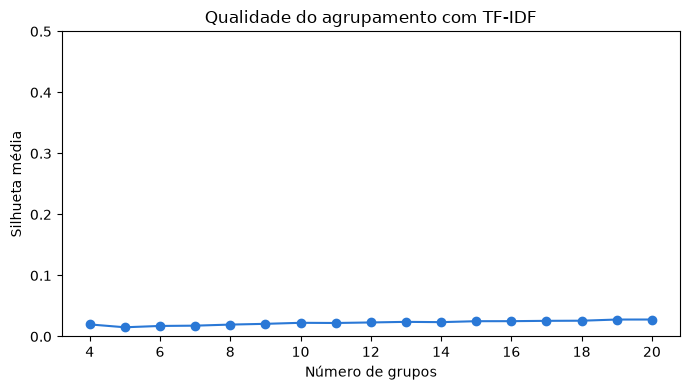

In [5]:
# ----------------------------------------------------------------------------------------------------
#                       GRÁFICO: QUALIDADE DO AGRUPAMENTO POR NÚMERO DE GRUPOS
# ----------------------------------------------------------------------------------------------------
plt.figure(figsize=(7, 4))                                                                  # tamanho do gráfico em polegadas
plt.plot(silhouette_per_k.index, silhouette_per_k.values, marker="o", color="#2a78d6")       # um ponto por número de grupos testado
plt.ylim(0, 0.5)                                                                            # escala inteira da silhueta útil, para não exagerar a subida
plt.xlabel("Número de grupos")                                                              # rótulo do eixo horizontal
plt.ylabel("Silhueta média")                                                                # rótulo do eixo vertical
plt.title("Qualidade do agrupamento com TF-IDF")                                            # título que vai junto no artigo
plt.tight_layout()                                                                          # evita cortar os rótulos
plt.savefig("../paper/latex/figures/silhouette_tfidf.png", dpi=150)                          # figura usada no artigo
plt.show()

A silhueta vai de 1, que seria grupos bem separados, até perto de 0, que é quando os grupos se
encostam e não dá para dizer onde um termina. Todos os valores ficaram rente ao zero. A curva sobe
de leve conforme aumentamos o número de grupos, mas isso acontece só porque picar um borrão em mais
pedaços deixa cada pedaço menor e mais compacto, e não porque apareceu separação de verdade.

Então este gráfico não escolhe o número de grupos para nós. Ele serve para dizer que as atividades
não formam ilhas. Quem escolhe é a etapa seguinte, que é a revisão manual: alguém do grupo lê cada
grupo e escreve o nome dele. Fixamos 16 porque é quanto conseguimos ler com atenção.

In [6]:
number_of_clusters = 16                                                                    # quantidade que conseguimos ler inteira para nomear

kmeans = KMeans(n_clusters=number_of_clusters, random_state=42, n_init=10)                  # semente fixa: rodando de novo dá o mesmo resultado
activities["cluster_tfidf"] = kmeans.fit_predict(tfidf_activities)                          # em que grupo cada atividade caiu

activities["cluster_tfidf"].value_counts().sort_index()

cluster_tfidf
0      43
1      20
2      25
3     101
4     102
5      34
6      43
7      76
8      21
9      23
10     24
11     35
12     49
13     39
14     32
15     26
Name: count, dtype: int64

In [7]:
# ====================================================================================================
#           OS GRUPOS ESTÃO SE FORMANDO POR ASSUNTO OU POR INSTITUIÇÃO?
# ====================================================================================================
source_per_cluster = pd.crosstab(activities["cluster_tfidf"], activities["source"])         # quantas atividades de cada instituição em cada grupo

source_per_cluster

source,Fábricas de Cultura,SESC
cluster_tfidf,,
0,8,35
1,2,18
2,0,25
3,18,83
4,5,97
5,33,1
6,33,10
7,18,58
8,0,21


In [8]:
# ----------------------------------------------------------------------------------------------------
#             MEDINDO O VAZAMENTO: O QUANTO CADA GRUPO É DE UMA INSTITUIÇÃO SÓ
# ----------------------------------------------------------------------------------------------------
largest_source_in_cluster = source_per_cluster.max(axis=1)                                             # quantas atividades tem a instituição dominante do grupo
cluster_sizes = source_per_cluster.sum(axis=1)                                                         # tamanho total de cada grupo
average_source_dominance = 100 * largest_source_in_cluster.sum() / cluster_sizes.sum()                  # média ponderada da dominância
single_source_clusters = (largest_source_in_cluster / cluster_sizes >= 0.9).sum()                       # grupos com 90% ou mais de uma instituição só
share_of_largest_source = 100 * activities["source"].value_counts().iloc[0] / len(activities)            # o quanto a maior instituição já é da base inteira

print("Se os grupos ignorassem a instituição, a dominância seria:", round(share_of_largest_source, 1), "%")
print("Dominância média observada dentro dos grupos:", round(average_source_dominance, 1), "%")
print("Grupos formados por 90% ou mais de uma única instituição:", single_source_clusters, "de", number_of_clusters)

Se os grupos ignorassem a instituição, a dominância seria: 81.4 %
Dominância média observada dentro dos grupos: 89.3 %
Grupos formados por 90% ou mais de uma única instituição: 11 de 16


A primeira linha é a referência que evita ler o número errado. Como o SESC já é a maior parte da
base, mesmo um agrupamento que ignorasse a instituição mostraria aquela porcentagem. O que acusa
problema é a diferença entre a segunda linha e a primeira, e principalmente os grupos que ficaram
com uma instituição só.

In [9]:
# ----------------------------------------------------------------------------------------------------
#               AS PALAVRAS QUE CAUSAM ISSO APARECEM NO CENTRO DOS GRUPOS
# ----------------------------------------------------------------------------------------------------
vocabulary_words = tfidf_vectorizer.get_feature_names_out()                                            # nome de cada coluna da matriz

for cluster_number in range(number_of_clusters):
    center_weights = pd.Series(kmeans.cluster_centers_[cluster_number], index=vocabulary_words)         # peso de cada palavra no centro do grupo
    cluster_terms = ", ".join(center_weights.sort_values(ascending=False).head(8).index)                # as 8 palavras que mais definem o grupo
    print("Grupo", cluster_number, "| SESC:", source_per_cluster.loc[cluster_number, "SESC"], "| Fábricas:", source_per_cluster.loc[cluster_number, "Fábricas de Cultura"], "|", cluster_terms)

Grupo 0 | SESC: 35 | Fábricas: 8 | corpo, sobre, negra, saúde, arte, espaço, descrição, encontrada
Grupo 1 | SESC: 18 | Fábricas: 2 | juventudes, acervo, espaço, biblioteca, adolescentes, livros, jogos, 13
Grupo 2 | SESC: 25 | Fábricas: 0 | inscrição, esporte, preenchidas, terceira, abertas, primeiros, cinco, remanescentes
Grupo 3 | SESC: 83 | Fábricas: 18 | esporte, atividade, prática, movimento, participantes, aula, modalidade, corrida
Grupo 4 | SESC: 97 | Fábricas: 5 | brasil, sobre, cinema, 10, história, pesquisa, curso, arte
Grupo 5 | SESC: 1 | Fábricas: 33 | fábrica, cultura, festival, capão, taipas, 14, especial, artes
Grupo 6 | SESC: 10 | Fábricas: 33 | histórias, biblioteca, equipe, sobre, vamos, sessão, contos, halloween
Grupo 7 | SESC: 58 | Fábricas: 18 | artes, arte, oficina, criação, participantes, sustentabilidade, sustentável, materiais
Grupo 8 | SESC: 21 | Fábricas: 0 | yoga, corporal, respiração, movimento, meditação, relaxamento, bem, consciência
Grupo 9 | SESC: 23 | 

Aparecem palavras como "sesc" e "equipe", essa última vindo de "com equipe biblioteca", que só as
Fábricas escrevem. Não é assunto de atividade nenhuma, é a assinatura de quem redigiu o texto.
Testamos então tirar essas palavras do vocabulário e refazer o agrupamento, para ver quanto do
problema elas explicam.

In [10]:
# ====================================================================================================
#             EXPERIMENTO: E SE O NOME DAS INSTITUIÇÕES SAIR DO VOCABULÁRIO?
# ====================================================================================================
institution_words = ["sesc", "fábrica", "fábricas", "fabrica", "fabricas", "unidade", "equipe", "sescsp"]     # assinatura de quem escreveu, não assunto
stopwords_of_the_experiment = portuguese_stopwords + institution_words                                        # a lista do idioma mais essas

tfidf_without_institution = TfidfVectorizer(stop_words=stopwords_of_the_experiment, min_df=3)                  # mesma configuração, vocabulário menor
matrix_without_institution = tfidf_without_institution.fit_transform(activities["text"])                       # mesma base, sem o nome das instituições

kmeans_without_institution = KMeans(n_clusters=number_of_clusters, random_state=42, n_init=10)                  # mesmo algoritmo, mesma semente
activities["cluster_tfidf_no_institution"] = kmeans_without_institution.fit_predict(matrix_without_institution)  # agrupamento do experimento

source_per_cluster_in_experiment = pd.crosstab(activities["cluster_tfidf_no_institution"], activities["source"])  # a mesma conferência de antes
source_per_cluster_in_experiment

source,Fábricas de Cultura,SESC
cluster_tfidf_no_institution,,
0,0,31
1,4,33
2,5,43
3,4,51
4,0,21
5,15,5
6,14,92
7,31,62
8,5,21


In [11]:
largest_source_in_experiment = source_per_cluster_in_experiment.max(axis=1)                                  # instituição dominante de cada grupo novo
cluster_sizes_in_experiment = source_per_cluster_in_experiment.sum(axis=1)                                   # tamanho de cada grupo novo
dominance_in_experiment = 100 * largest_source_in_experiment.sum() / cluster_sizes_in_experiment.sum()        # mesma média ponderada de antes

print("Dominância da instituição antes de remover:", round(average_source_dominance, 1), "%")
print("Dominância da instituição depois de remover:", round(dominance_in_experiment, 1), "%")
print("Grupos com 90% ou mais de uma única instituição, depois:", (largest_source_in_experiment / cluster_sizes_in_experiment >= 0.9).sum(), "de", number_of_clusters)

Dominância da instituição antes de remover: 89.3 %
Dominância da instituição depois de remover: 86.1 %
Grupos com 90% ou mais de uma única instituição, depois: 7 de 16


Melhorou, mas duas coisas nos incomodaram nesse resultado.

A primeira é que o vazamento não sumiu. A marca da instituição não está só em duas ou três palavras,
ela está no jeito de escrever inteiro, e contar palavra não consegue separar assunto de estilo.

A segunda é mais séria para o nosso projeto. A proposta é uma API que recebe a descrição de uma
atividade de qualquer instituição, inclusive de uma que a gente nunca viu. Não teria como montar
antes a lista de palavras a remover dessa instituição nova. Essa limpeza só funciona porque nós já
sabemos de onde os dados vieram, então ela serve como experimento, mas não serve como solução.

In [12]:
# ====================================================================================================
#                         OS GRUPOS QUE O TF-IDF ENCONTROU, PARA LEITURA
# ====================================================================================================
experiment_words = tfidf_without_institution.get_feature_names_out()                                                   # vocabulário do agrupamento final

terms_per_cluster = {}                                                                                                 # grupo -> palavras que o caracterizam
for cluster_number in range(number_of_clusters):
    center_weights = pd.Series(kmeans_without_institution.cluster_centers_[cluster_number], index=experiment_words)     # peso de cada palavra no centro
    terms_per_cluster[cluster_number] = ", ".join(center_weights.sort_values(ascending=False).head(10).index)           # as 10 palavras que mais definem

for cluster_number in range(number_of_clusters):
    cluster_activities = activities[activities["cluster_tfidf_no_institution"] == cluster_number]                       # só as atividades desse grupo
    print("=" * 100)
    print("GRUPO", cluster_number, "-", len(cluster_activities), "atividades |", terms_per_cluster[cluster_number])
    for activity_title in cluster_activities["title"].head(4):
        print("   -", activity_title)

GRUPO 0 - 31 atividades | vagas, credencial, esporte, plena, 1ª, 3ª, feira, mês, quinta, 18h
   - Esporte Adulto - Iniciação à Corrida
   - Movimento Consciente
   - Esporte Adulto - Vôlei
   - Esporte para Pessoas Idosas - Multimodalidades
GRUPO 1 - 37 atividades | têxtil, oficina, costura, técnicas, criação, peças, participantes, tecelagem, confecção, autoral
   - OFICINA DE TIRINHA AUTOBIOGRÁFICA PARA POSTAR NO FEED – COM FELIPE PARUCCI
   - MANTO DO INVISÍVEL: MEMÓRIAS EM PRODUÇÕES TÊXTEIS
   - MODA QUE TRANSFORMA: OFICINA DE UPCYCLING E SUSTENTABILIDADE
   - 6° EXTREMUM FEST
GRUPO 2 - 48 atividades | livro, livros, leitura, sobre, literatura, autora, mulheres, pessoas, projeto, encontros
   - DESESTRESSAR PINTANDO: A ARTE DE RELAXAR COM LIVROS DE COLORIR – COM EQUIPE BIBLIOTECA
   - ABEBÉ DA MEMÓRIA: OFICINA PERFORMANCE PARA CRIANÇAS – COM COLETIVO AJÔ ARÔ
   - LANÇAMENTO DO LIVRO SKATE&CORES
   - OUTUBRO ROSA: SAÚDE DA MULHER EM PAUTA
GRUPO 3 - 55 atividades | artes, arte, sobre,

In [13]:
activities.to_csv("../data/processed/activities_clustered_tfidf.csv", sep=";", index=False, encoding="utf-8-sig")   # agrupamento da representação de comparação

print("Agrupamento salvo em data/processed/activities_clustered_tfidf.csv")

Agrupamento salvo em data/processed/activities_clustered_tfidf.csv
